<a href="https://colab.research.google.com/github/YuliaLoburets/A-B-test_project/blob/main/A_B_Testing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated successfully')

Authenticated successfully


In [16]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import matplotlib.ticker as ticker
warnings.filterwarnings('ignore')

In [15]:

# ── CONFIG ──────────────────────────────────────────────
PROJECT_ID = 'testproject-470912'
DATASET    = 'pricing_experiment.car_usage_data'
# ────────────────────────────────────────────────────────

client = bigquery.Client(project=PROJECT_ID)

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

def run_query(sql):
    """Run a BigQuery SQL query and return a pandas DataFrame."""
    return client.query(sql).to_dataframe()

print('Setup complete')

Setup complete


In [3]:
desired_width=320
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', 20)

In [4]:
overview_query = f"""
SELECT *
FROM `{DATASET}`
"""
overview = run_query(overview_query)
overview.head(10)

,rent_id,user_id,start_dt,end_dt,cost,type_,car_class,flag_ftr
0,7266017499955140000,6341823040309490000,48:26.0,26:57.0,-1250.0,Short rent,Comfort,0
1,2694397645716480000,7486465028761380000,03:01.0,39:21.0,0.0,Long rent,Comfort,1
2,3822972942289750000,8733503588685500000,02:09.0,40:36.0,0.0,Long rent,Comfort,1
3,16633516079053600,6696377725323650000,47:49.0,05:03.0,0.0,Long rent,Comfort,1
4,578314446309090000,6362516843803520000,56:10.0,03:06.0,0.0,Short rent,Comfort,1
5,3051109028683770000,7307266763897690000,30:47.0,24:34.0,0.0,Long rent,Comfort,1
6,8574504883423410000,9192171768180830000,43:48.0,50:42.0,0.0,Long rent,Comfort,-1
7,8764416851180600000,9089247902658340000,23:58.0,25:43.0,0.0,Long rent,Comfort,-1
8,9175531106799080000,5412519947454960000,08:43.0,42:16.0,0.0,Long rent,Comfort,1
9,8154826257376720000,3727813601910090000,28:06.0,09:57.0,0.0,Long rent,Comfort,-1


In [5]:
overview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316469 entries, 0 to 316468
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   rent_id    316469 non-null  Int64  
 1   user_id    316469 non-null  Int64  
 2   start_dt   316469 non-null  object 
 3   end_dt     316469 non-null  object 
 4   cost       316469 non-null  float64
 5   type_      316469 non-null  object 
 6   car_class  316469 non-null  object 
 7   flag_ftr   316469 non-null  Int64  
dtypes: Int64(3), float64(1), object(4)
memory usage: 20.2+ MB


In [6]:
overview['cost'].describe()

,cost
count,316469.000000
mean,1663.399864
std,2302.953421
min,-1250.000000
25%,731.250000
50%,1239.583333
75%,1956.250000
max,425839.583300


In [7]:
dup = overview.groupby('user_id').agg(duplicates=('user_id','count')).reset_index()
dup.sort_values(by='duplicates', ascending=False)

,user_id,duplicates
6447,1615995789360480000,791
27832,6993220522717430000,367
35606,8998651449142730000,358
19082,4804034955114900000,319
7388,1845710661862130000,318
...,...,...
12208,3051291031027250000,1
12207,3051112852452310000,1
25,6314533619391700,1
14,2724197947325470,1


In [8]:
user_overview = overview.groupby('user_id').agg(rentals=('rent_id', 'count'), total_cost = ('cost', 'sum'), median_cost = ('cost', 'median'), mean_cost = ('cost', 'mean'), max_cost = ('cost', 'max'), min_cost = ('cost','min')).round(1)
user_overview

,rentals,total_cost,median_cost,mean_cost,max_cost,min_cost
user_id,,,,,,
262012071872478,3,4260.4,1285.4,1420.1,1872.9,1102.1
425451464049489,4,6825.0,1358.3,1706.2,3429.2,679.2
630029854204664,7,5572.9,822.9,796.1,1166.7,502.1
820471154260126,1,2770.8,2770.8,2770.8,2770.8,2770.8
952030444175947,1,2527.1,2527.1,2527.1,2527.1,2527.1
...,...,...,...,...,...,...
9222597610146270000,1,1283.3,1283.3,1283.3,1283.3,1283.3
9222785679483690000,1,8606.2,8606.2,8606.2,8606.2,8606.2
9222868814946190000,3,2345.8,460.4,781.9,1500.0,385.4


In [9]:
user_overview.describe()

,rentals,total_cost,median_cost,mean_cost,max_cost,min_cost
count,36484.0,3.648400e+04,36484.000000,36484.000000,36484.000000,36484.000000
mean,8.674186,1.442864e+04,1595.555811,1744.385013,3214.898616,982.643364
std,15.086891,2.981754e+04,1784.914532,2068.292185,4800.842231,1613.071858
min,1.0,-5.229000e+02,-261.500000,-261.500000,-206.200000,-1250.000000
25%,1.0,2.008300e+03,866.700000,969.600000,1350.000000,314.600000
50%,3.0,5.450000e+03,1293.800000,1408.300000,2216.700000,658.300000
75%,9.0,1.521880e+04,1856.200000,2008.300000,3673.425000,1204.200000
max,791.0,1.889585e+06,93770.800000,157874.300000,425839.600000,93770.800000


In [10]:
user_overview['frequency_segment'] = pd.qcut(user_overview['rentals'],q=3, labels = ['Low', 'Medium','High'])
user_overview['cost_segment'] = pd.qcut(user_overview['total_cost'], q=3, labels = ['Low', 'Medium','High'])

In [11]:
user_overview

,rentals,total_cost,median_cost,mean_cost,max_cost,min_cost,frequency_segment,cost_segment
user_id,,,,,,,,
262012071872478,3,4260.4,1285.4,1420.1,1872.9,1102.1,Medium,Medium
425451464049489,4,6825.0,1358.3,1706.2,3429.2,679.2,Medium,Medium
630029854204664,7,5572.9,822.9,796.1,1166.7,502.1,Medium,Medium
820471154260126,1,2770.8,2770.8,2770.8,2770.8,2770.8,Low,Low
952030444175947,1,2527.1,2527.1,2527.1,2527.1,2527.1,Low,Low
...,...,...,...,...,...,...,...,...
9222597610146270000,1,1283.3,1283.3,1283.3,1283.3,1283.3,Low,Low
9222785679483690000,1,8606.2,8606.2,8606.2,8606.2,8606.2,Low,Medium
9222868814946190000,3,2345.8,460.4,781.9,1500.0,385.4,Medium,Low


In [12]:
user_overview.groupby('frequency_segment').agg(avg_rentals=('rentals','mean'), median_cost = ('total_cost','median'), users = ('rentals','count')).round(1)

,avg_rentals,median_cost,users
frequency_segment,,,
Low,1.4,1710.4,14782
Medium,4.5,6275.0,10773
High,22.7,24716.7,10929


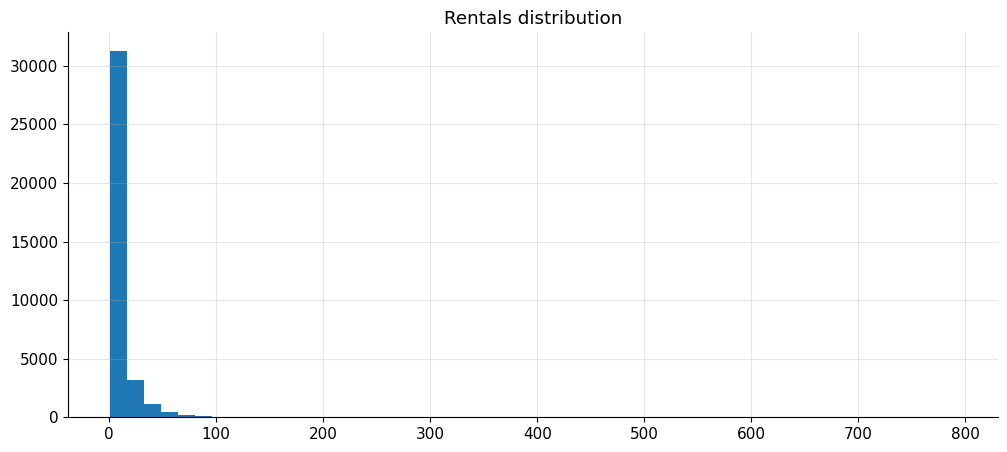

In [23]:
user_overview['rentals'].hist(bins=50)
plt.title('Rentals distribution')
plt.show()

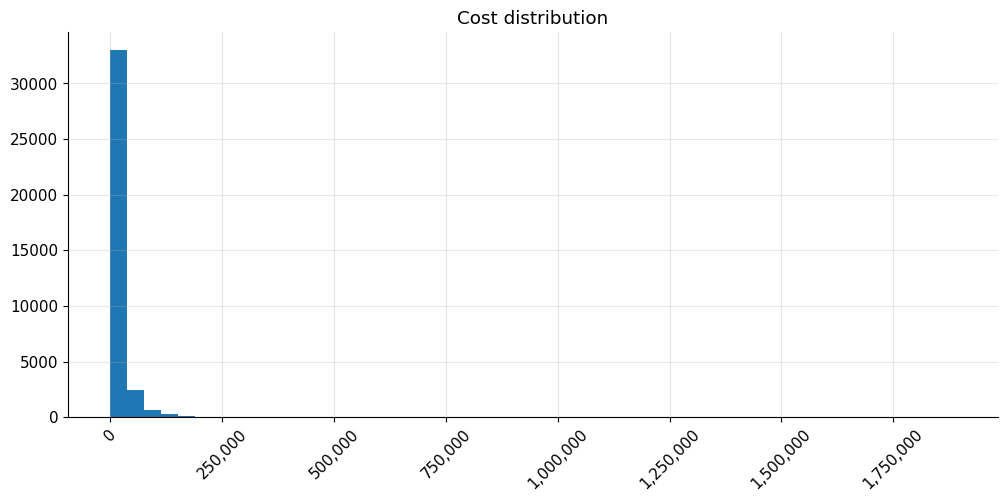

In [19]:
ax = user_overview['total_cost'].hist(bins=50)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.xticks(rotation=45)
plt.title('Cost distribution')
plt.show()

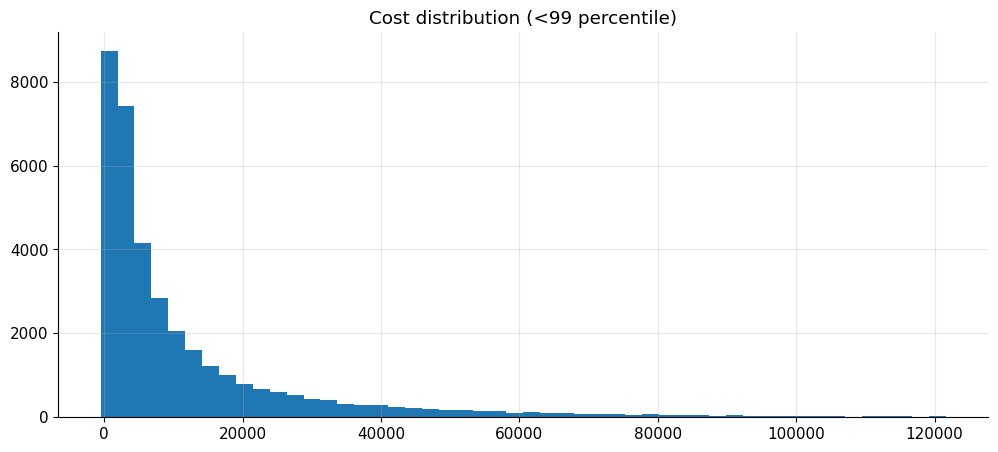

In [28]:
q99 = user_overview['total_cost'].quantile(0.99)
cost_less_q99 =  user_overview.query('total_cost < @q99')
cost_less_q99['total_cost'].hist(bins=50)
plt.title('Cost distribution (<99 percentile)')
plt.show()

Text(0.5, 1.0, 'Log cost distribution')

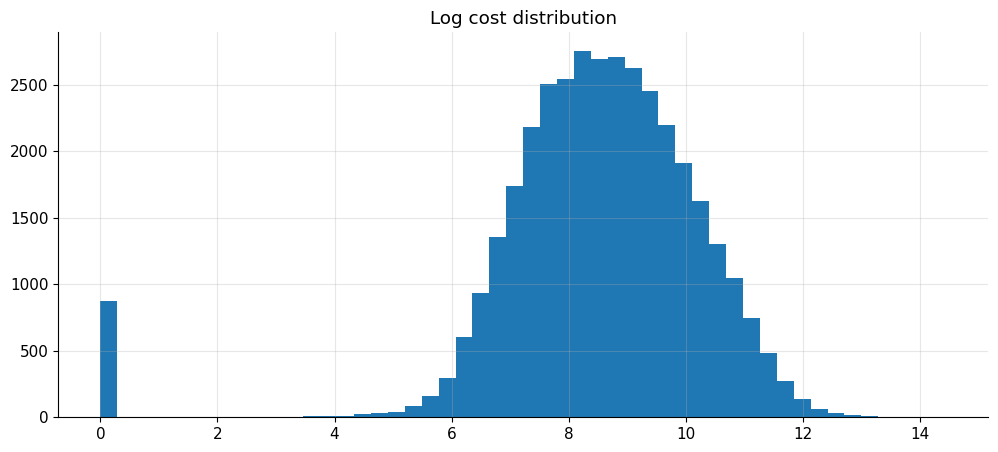

In [30]:
np.log1p(user_overview['total_cost']).hist(bins=50)
plt.title('Log cost distribution')

The spending distribution is heavily right-skewed. After log transformation, the distribution becomes approximately bell-shaped, revealing the presence of a distinct group of users with zero spending and a large central group with moderate spending levels.

In [38]:
round(overview.query('cost <=0').shape[0]/overview.shape[0]*100,1)

2.4

Only 2.4% of transactions have non-positive values. The presence of zero and negative transactions suggests promotional activities, refunds, cancellations, or accounting adjustments. Since their business meaning is not documented and the share is relatively small, they were retained in the exploratory analysis and flagged as a potential area for further business validation

In [19]:
user_overview.groupby('cost_segment').agg(avg_rentals=('rentals','mean'), median_cost = ('total_cost','median'), users = ('rentals','count')).round(1)

,avg_rentals,median_cost,users
cost_segment,,,
Low,1.5,1353.2,12166
Medium,4.1,5452.1,12158
High,20.4,23490.6,12160
